In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

plt.style.use('ggplot')
sns.set_context("talk")

In [3]:
df_sales = pd.read_csv('data/sales_train_validation.csv')
df_calendar = pd.read_csv('data/calendar.csv')
df_prices = pd.read_csv('data/sell_prices.csv')

In [4]:
df_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [5]:
def memory_optimization(df):
    id_vars = df.select_dtypes(include=['object']).columns
    for col in id_vars:
        df[col] = df[col].astype('category')

    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df.info(memory_usage='deep')

In [6]:
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_melted = pd.melt(df_sales, id_vars = id_vars, var_name = 'd', value_name = 'sales')
del df_sales
gc.collect()
df_melted.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        object
 1   item_id   object
 2   dept_id   object
 3   cat_id    object
 4   store_id  object
 5   state_id  object
 6   d         object
 7   sales     int64 
dtypes: int64(1), object(7)
memory usage: 22.8 GB


In [7]:
memory_optimization(df_melted)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 8 columns):
 #   Column    Dtype   
---  ------    -----   
 0   id        category
 1   item_id   category
 2   dept_id   category
 3   cat_id    category
 4   store_id  category
 5   state_id  category
 6   d         category
 7   sales     int16   
dtypes: category(7), int16(1)
memory usage: 671.2 MB


In [8]:
df_sales_calendar = pd.merge(df_melted, df_calendar, on='d', how='left')
del df_calendar
del df_melted
gc.collect()
df_sales_calendar.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 21 columns):
 #   Column        Dtype   
---  ------        -----   
 0   id            category
 1   item_id       category
 2   dept_id       category
 3   cat_id        category
 4   store_id      category
 5   state_id      category
 6   d             object  
 7   sales         int16   
 8   date          object  
 9   wm_yr_wk      int64   
 10  weekday       object  
 11  wday          int64   
 12  month         int64   
 13  year          int64   
 14  event_name_1  object  
 15  event_type_1  object  
 16  event_name_2  object  
 17  event_type_2  object  
 18  snap_CA       int64   
 19  snap_TX       int64   
 20  snap_WI       int64   
dtypes: category(6), int16(1), int64(7), object(7)
memory usage: 20.0 GB


In [9]:
memory_optimization(df_sales_calendar)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 21 columns):
 #   Column        Dtype   
---  ------        -----   
 0   id            category
 1   item_id       category
 2   dept_id       category
 3   cat_id        category
 4   store_id      category
 5   state_id      category
 6   d             category
 7   sales         int16   
 8   date          category
 9   wm_yr_wk      int16   
 10  weekday       category
 11  wday          int8    
 12  month         int8    
 13  year          int16   
 14  event_name_1  category
 15  event_type_1  category
 16  event_name_2  category
 17  event_type_2  category
 18  snap_CA       int8    
 19  snap_TX       int8    
 20  snap_WI       int8    
dtypes: category(13), int16(3), int8(5)
memory usage: 1.5 GB


In [10]:
df = pd.merge(df_sales_calendar, df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_sales_calendar
del df_prices
gc.collect()
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 22 columns):
 #   Column        Dtype   
---  ------        -----   
 0   id            category
 1   item_id       object  
 2   dept_id       category
 3   cat_id        category
 4   store_id      object  
 5   state_id      category
 6   d             category
 7   sales         int16   
 8   date          category
 9   wm_yr_wk      int16   
 10  weekday       category
 11  wday          int8    
 12  month         int8    
 13  year          int16   
 14  event_name_1  category
 15  event_type_1  category
 16  event_name_2  category
 17  event_type_2  category
 18  snap_CA       int8    
 19  snap_TX       int8    
 20  snap_WI       int8    
 21  sell_price    float64 
dtypes: category(11), float64(1), int16(3), int8(5), object(2)
memory usage: 8.0 GB


In [11]:
memory_optimization(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 22 columns):
 #   Column        Dtype   
---  ------        -----   
 0   id            category
 1   item_id       category
 2   dept_id       category
 3   cat_id        category
 4   store_id      category
 5   state_id      category
 6   d             category
 7   sales         int16   
 8   date          category
 9   wm_yr_wk      int16   
 10  weekday       category
 11  wday          int8    
 12  month         int8    
 13  year          int16   
 14  event_name_1  category
 15  event_type_1  category
 16  event_name_2  category
 17  event_type_2  category
 18  snap_CA       int8    
 19  snap_TX       int8    
 20  snap_WI       int8    
 21  sell_price    float16 
dtypes: category(13), float16(1), int16(3), int8(5)
memory usage: 1.6 GB


In [12]:
nulos_precio = df['sell_price'].isnull().sum()
print(nulos_precio)
error_check = df[(df['sales'] > 0) & (df['sell_price'].isnull())]
print(len(error_check))
df['revenue'] = df['sales'] * df['sell_price']
df['revenue'] = df['revenue'].fillna(0)

12299413
0


In [13]:
df['date'] = pd.to_datetime(df['date'])
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 23 columns):
 #   Column        Dtype   
---  ------        -----   
 0   id            category
 1   item_id       category
 2   dept_id       category
 3   cat_id        category
 4   store_id      category
 5   state_id      category
 6   d             category
 7   sales         int16   
 8   date          category
 9   wm_yr_wk      int16   
 10  weekday       category
 11  wday          int8    
 12  month         int8    
 13  year          int16   
 14  event_name_1  category
 15  event_type_1  category
 16  event_name_2  category
 17  event_type_2  category
 18  snap_CA       int8    
 19  snap_TX       int8    
 20  snap_WI       int8    
 21  sell_price    float16 
 22  revenue       float32 
dtypes: category(13), float16(1), float32(1), int16(3), int8(5)
memory usage: 1.9 GB


In [57]:
df.head()

c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,revenue,is_event,snap_active,day_of_month
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,NaN,0.0,False,False,29
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,NaN,0.0,False,False,29
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,NaN,0.0,False,False,29
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,NaN,0.0,False,False,29
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,NaN,0.0,False,False,29


c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\Santi\Documents\m5_forecasting_accuracy\venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [56]:
df['sales'].describe()

count    5.832737e+07
mean     1.126322e+00
std      3.873108e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      7.630000e+02
Name: sales, dtype: float64

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\924530294.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_state = df.groupby('state_id')['revenue'].sum().sort_values(ascending=False)
C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\924530294.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_store = df.groupby('store_id')['revenue'].sum().sort_values(ascending=False)


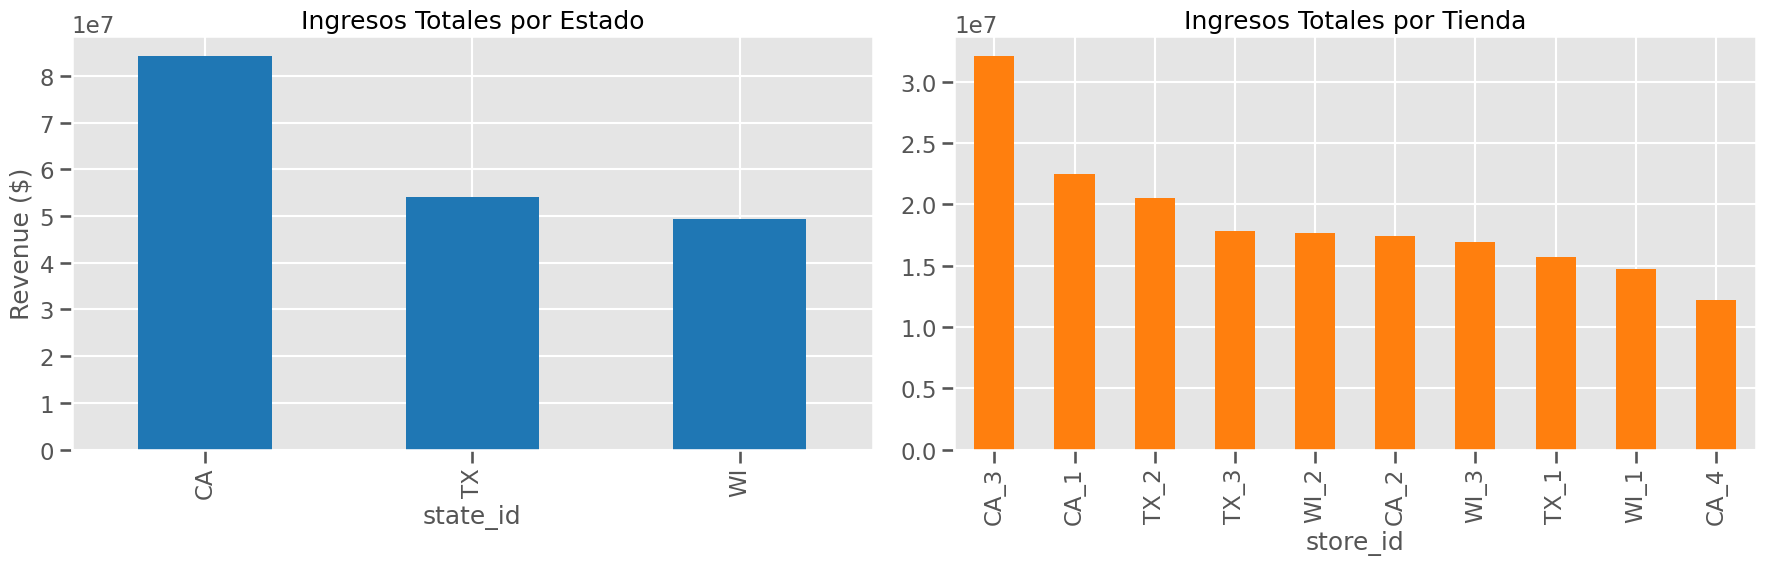

In [14]:
rev_by_state = df.groupby('state_id')['revenue'].sum().sort_values(ascending=False)

rev_by_store = df.groupby('store_id')['revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rev_by_state.plot(kind='bar', color='#1f77b4', ax=axes[0])
axes[0].set_title('Ingresos Totales por Estado')
axes[0].set_ylabel('Revenue ($)')

rev_by_store.plot(kind='bar', color='#ff7f0e', ax=axes[1])
axes[1].set_title('Ingresos Totales por Tienda')

plt.tight_layout()
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\1259265052.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_cat = df.groupby('cat_id')['revenue'].sum().sort_values(ascending=False)
C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\1259265052.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_dept = df.groupby('dept_id')['revenue'].sum().sort_values(ascending=False)


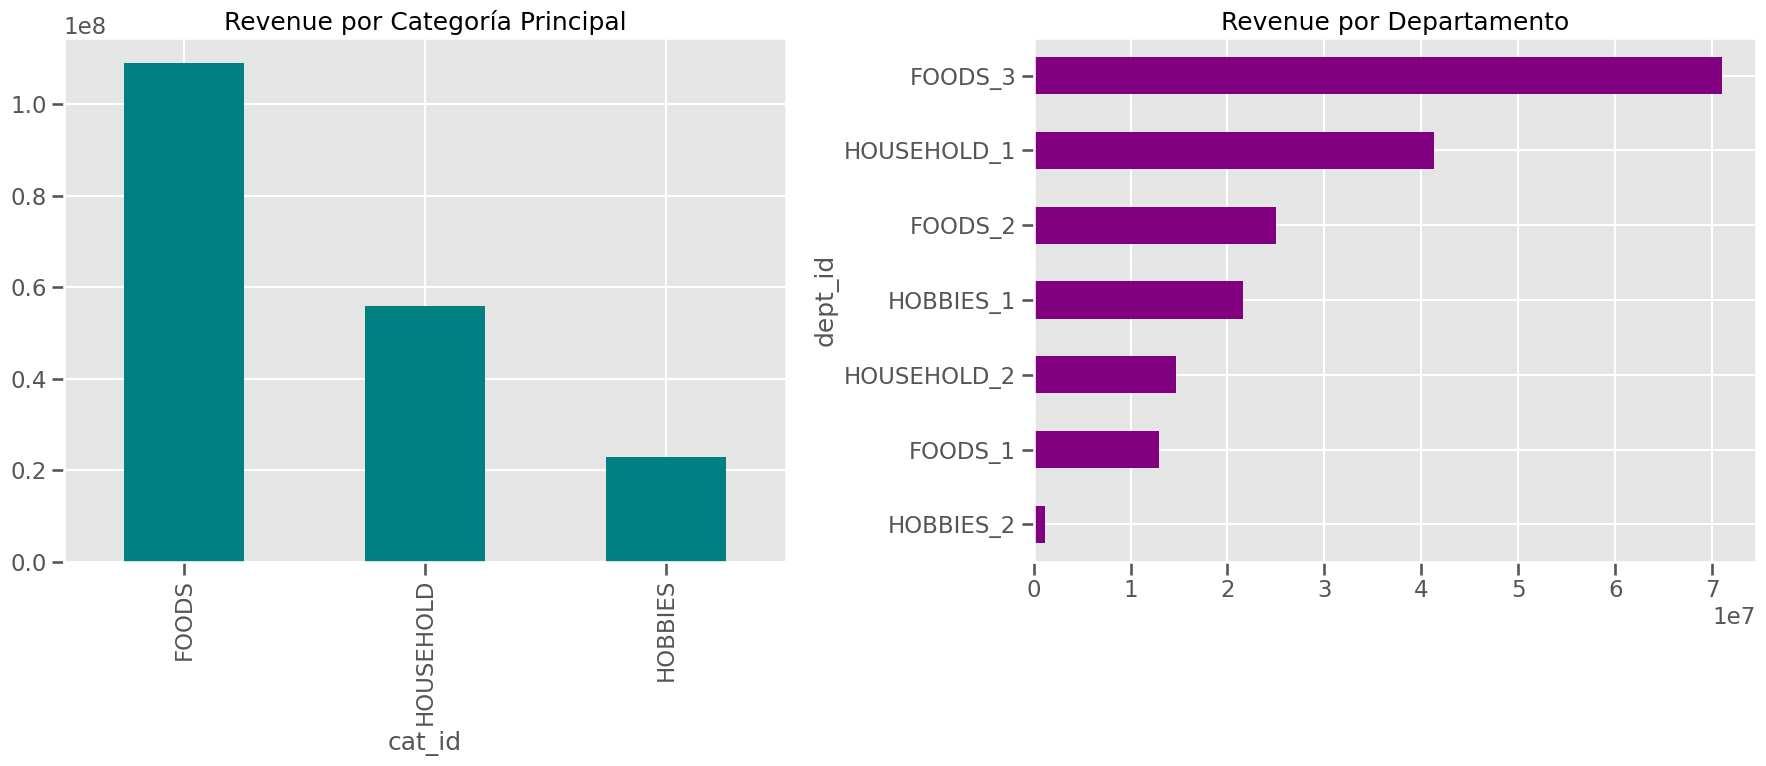

In [15]:
rev_by_cat = df.groupby('cat_id')['revenue'].sum().sort_values(ascending=False)

rev_by_dept = df.groupby('dept_id')['revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

rev_by_cat.plot(kind='bar', color='teal', ax=axes[0])
axes[0].set_title('Revenue por Categoría Principal')

rev_by_dept.plot(kind='barh', color='purple', ax=axes[1]) # 'barh' es barras horizontales
axes[1].set_title('Revenue por Departamento')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\3536816361.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat_state = df.groupby(['state_id', 'cat_id'])['revenue'].sum().unstack()
C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\3536816361.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dep_state = df.groupby(['state_id', 'dept_id'])['revenue'].sum().unstack()


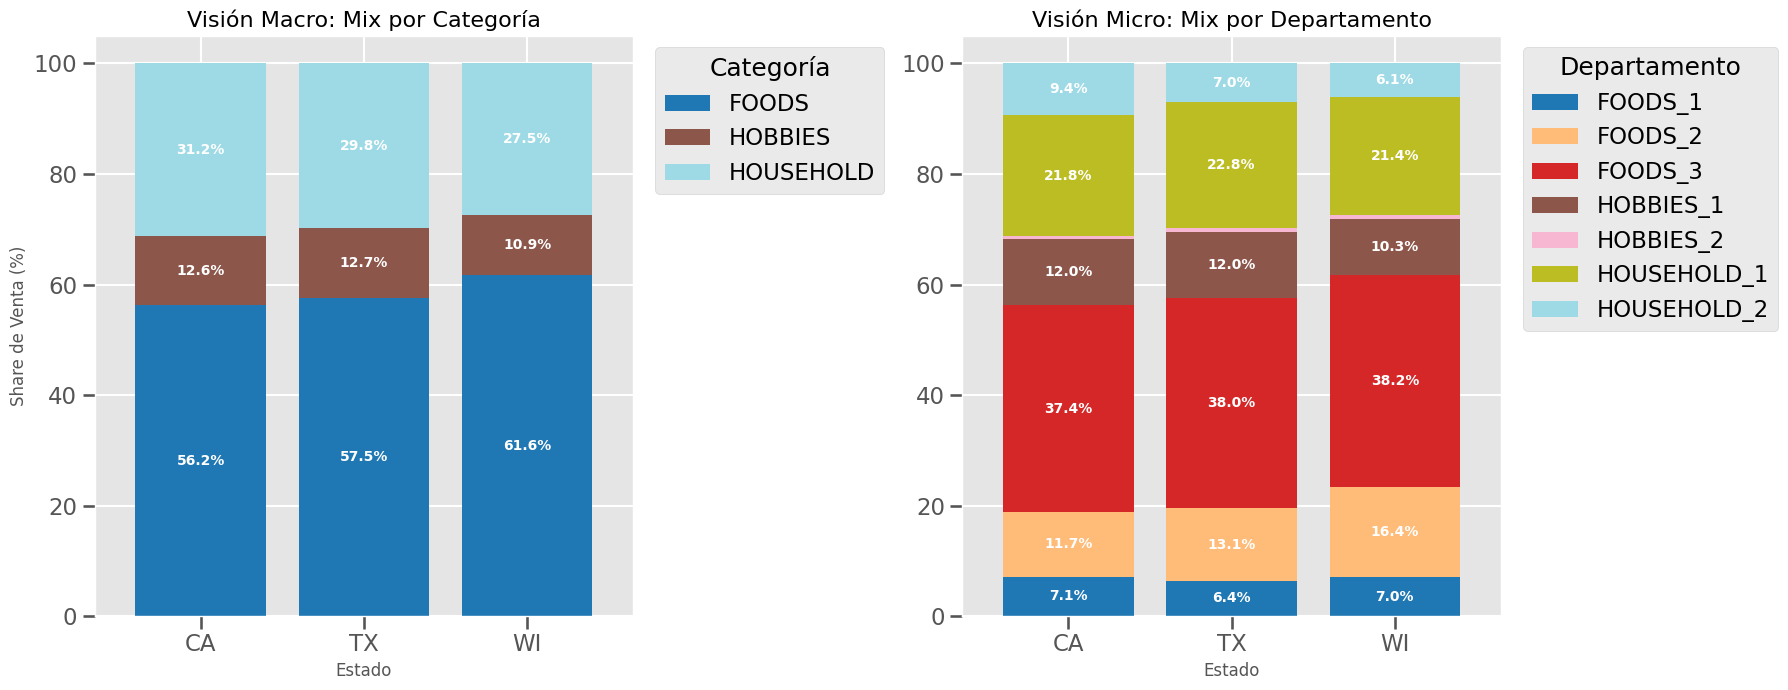

In [27]:
# Configuración estética global

# 1. Preparar los datos (Igual que tenías)
df_cat_state = df.groupby(['state_id', 'cat_id'])['revenue'].sum().unstack()
df_dep_state = df.groupby(['state_id', 'dept_id'])['revenue'].sum().unstack()

# Calcular porcentajes
df_percent_cat = df_cat_state.div(df_cat_state.sum(axis=1), axis=0) * 100
df_percent_dep = df_dep_state.div(df_dep_state.sum(axis=1), axis=0) * 100

# 2. Configurar el Canvas (Lienzo)
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Un poco más ancho para que respire

# --- GRÁFICO 1: CATEGORÍA (Izquierda) ---
# Usamos colormap 'Set2' o 'viridis' para pocos datos
df_percent_cat.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20', width=0.8)
axes[0].set_title('Visión Macro: Mix por Categoría', fontsize=16)
axes[0].set_ylabel('Share de Venta (%)')
axes[0].set_xlabel('Estado')
axes[0].tick_params(axis='x', rotation=0) # Texto horizontal
axes[0].legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- GRÁFICO 2: DEPARTAMENTO (Derecha) ---
# Usamos 'tab20' porque hay muchos departamentos y necesitamos contraste
df_percent_dep.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', width=0.8)
axes[1].set_title('Visión Micro: Mix por Departamento', fontsize=16)
axes[1].set_ylabel('') # Quitamos etiqueta redundante
axes[1].set_xlabel('Estado')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- LA MAGIA: ETIQUETADO INTELIGENTE ---
# Iteramos por cada eje (ax) por separado
for ax in axes:
    for c in ax.containers:
        # Aquí está el filtro: Solo creamos etiqueta si el valor es > 4%
        # Si es menor, ponemos una cadena vacía ''
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 4 else '' for v in c]
        
        # Aplicamos las etiquetas
        ax.bar_label(c, labels=labels, label_type='center', color='white', 
                     weight='bold', fontsize=10, padding=0)

plt.tight_layout()
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\80495230.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_dept_mix = df.groupby(['store_id', 'cat_id'])['revenue'].sum().unstack()


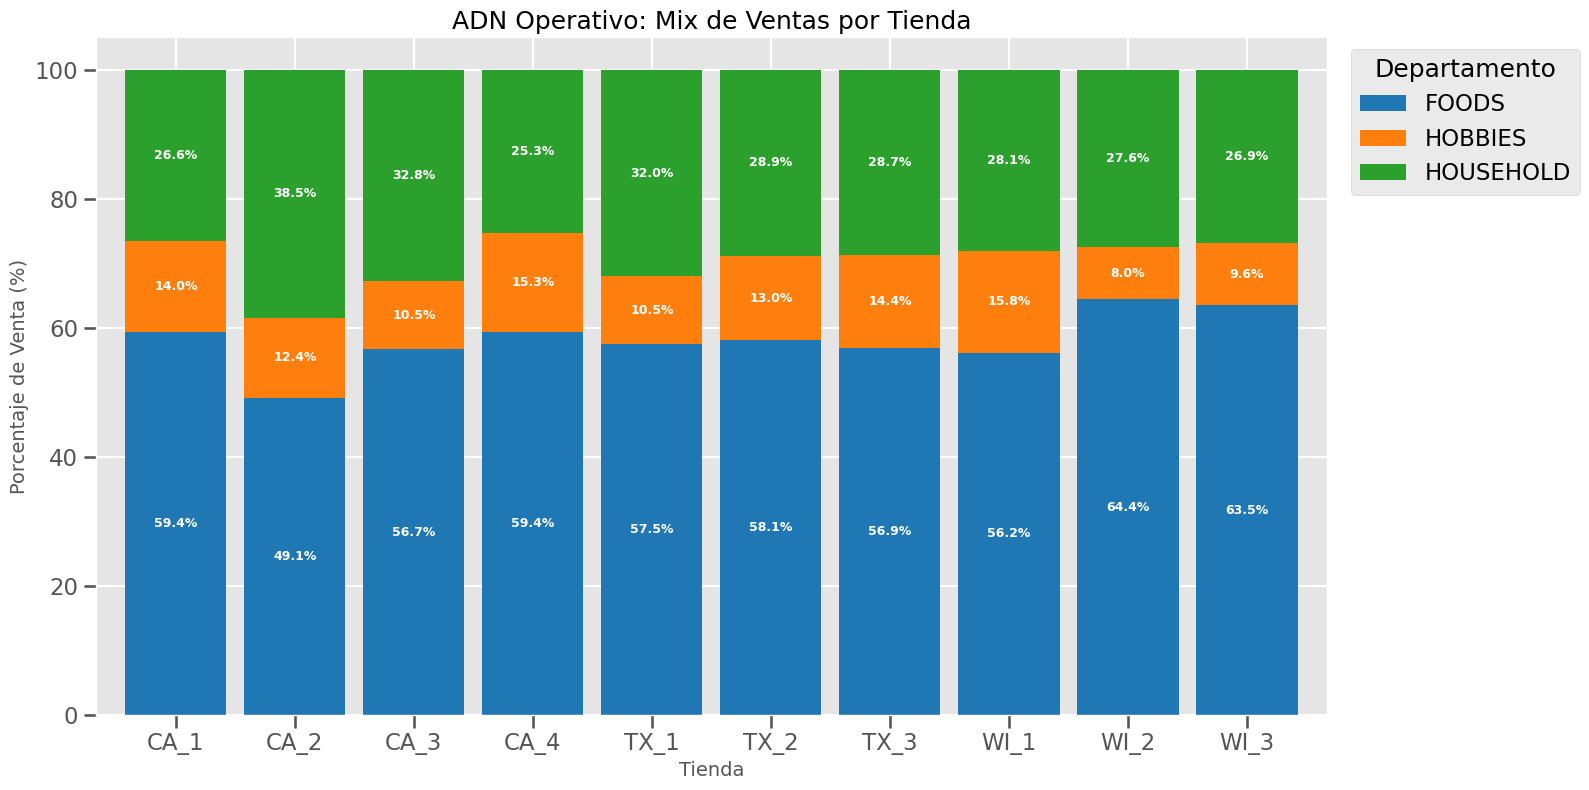

In [28]:

plt.style.use('ggplot')
sns.set_palette("tab10") # Colores variados para los 7 departamentos

# 1. Preparar los datos: Agrupar por Tienda y Departamento
# Unstack convierte los departamentos en columnas
store_dept_mix = df.groupby(['store_id', 'cat_id'])['revenue'].sum().unstack()

# 2. Calcular porcentajes (Normalización al 100%)
# Dividimos cada fila por su total y multiplicamos por 100
store_percent = store_dept_mix.div(store_dept_mix.sum(axis=1), axis=0) * 100

# 3. Graficar
fig, ax = plt.subplots(figsize=(16, 8)) # Hacemos el gráfico ancho
store_percent.plot(kind='bar', stacked=True, width=0.85, ax=ax)

# 4. Decoración y Etiquetas
ax.set_title('ADN Operativo: Mix de Ventas por Tienda', fontsize=18)
ax.set_ylabel('Porcentaje de Venta (%)', fontsize=14)
ax.set_xlabel('Tienda', fontsize=14)
plt.xticks(rotation=0) # Tiendas en horizontal para leer mejor
ax.legend(title='Departamento', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Etiquetas de Datos (Solo mostramos si el segmento es > 5% para limpieza)
for c in ax.containers:
    # Creamos etiquetas personalizadas
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
    # Las ponemos en el centro de cada barra
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\1219586766.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wday_rev = df.groupby('weekday')['revenue'].mean().reindex(order_days)


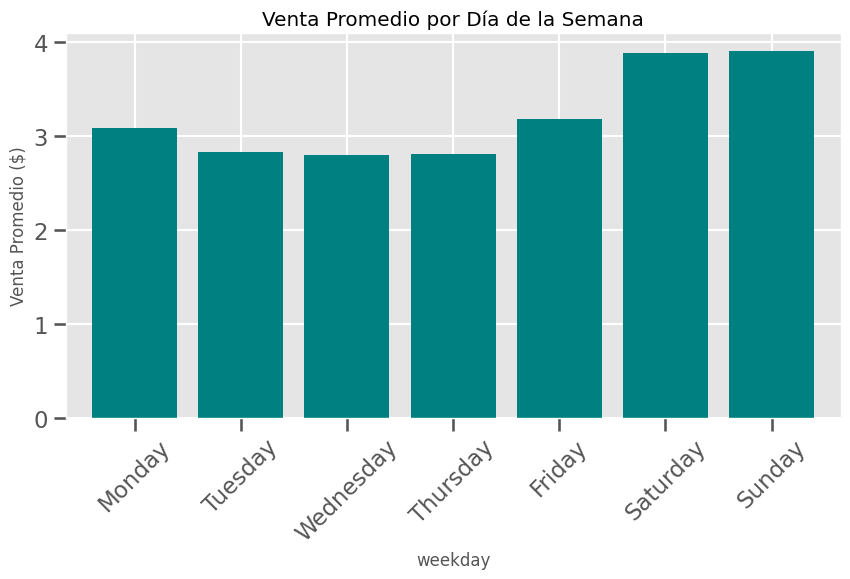

In [31]:
# Usamos el nombre del día (weekday) para que sea legible
# OJO: Asegúrate de ordenar los días (Lunes, Martes...) si no salen desordenados
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Agrupamos por día y sacamos el PROMEDIO (Mean) de venta diaria
# Usamos promedio porque hay más lunes que domingos en la historia, la suma podría engañar
wday_rev = df.groupby('weekday')['revenue'].mean().reindex(order_days)

plt.figure(figsize=(10, 5))
wday_rev.plot(kind='bar', color='teal', width=0.8)

plt.title('Venta Promedio por Día de la Semana')
plt.ylabel('Venta Promedio ($)')
plt.xticks(rotation=45)
plt.show()

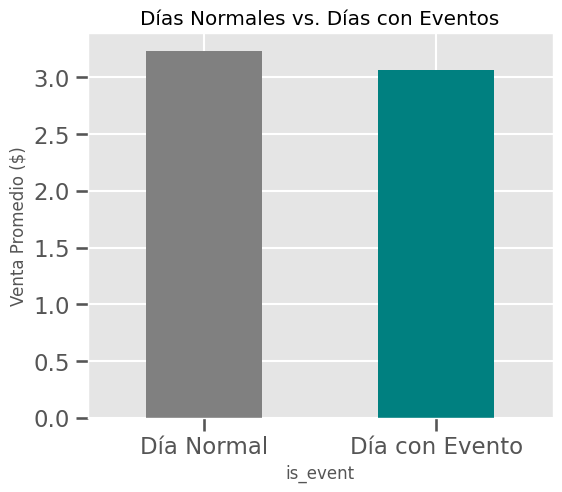

In [34]:
# Vamos a crear una columna simple: ¿Es día de evento o no?
# Si 'event_name_1' no es nulo, es evento.
df['is_event'] = df['event_name_1'].notnull() | df['event_name_2'].notnull()

# Comparamos promedios
event_impact = df.groupby('is_event')['revenue'].mean()

plt.figure(figsize=(6, 5))
event_impact.plot(kind='bar', color=['gray', 'teal'])
plt.title('Días Normales vs. Días con Eventos')
plt.xticks([0, 1], ['Día Normal', 'Día con Evento'], rotation=0)
plt.ylabel('Venta Promedio ($)')
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\655258639.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  event_ranking = df.groupby('event_name_1')['revenue'].mean().sort_values(ascending=False)


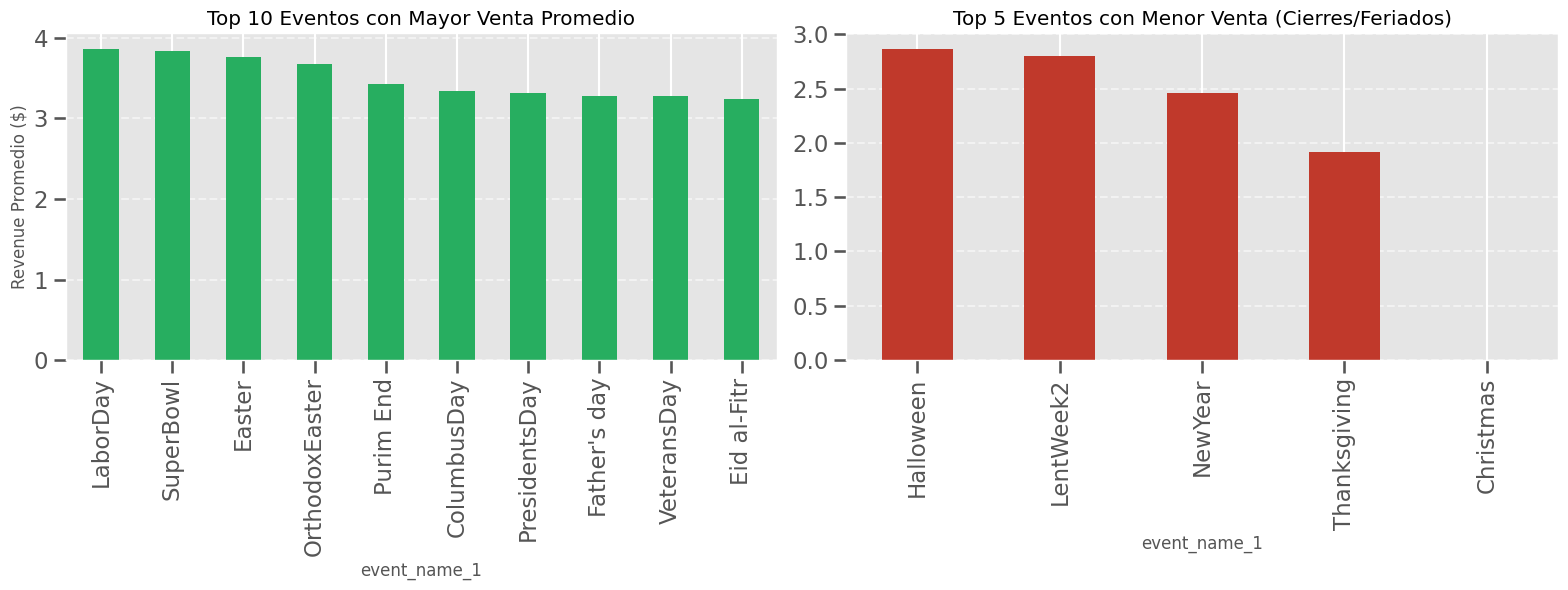

In [35]:
# 1. Agrupamos por nombre del evento
# Usamos 'mean' para ser justos (porque algunos eventos ocurren más veces que otros)
event_ranking = df.groupby('event_name_1')['revenue'].mean().sort_values(ascending=False)

# 2. Sacamos el Top 10 y el Bottom 5
top_events = event_ranking.head(10)
bottom_events = event_ranking.tail(5) # Para ver los días malos

# 3. Graficamos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Ganadores
top_events.plot(kind='bar', ax=axes[0], color='#27ae60')
axes[0].set_title('Top 10 Eventos con Mayor Venta Promedio')
axes[0].set_ylabel('Revenue Promedio ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico de Perdedores
bottom_events.plot(kind='bar', ax=axes[1], color='#c0392b')
axes[1].set_title('Top 5 Eventos con Menor Venta (Cierres/Feriados)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\109299543.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_item = df.groupby('item_id')['revenue'].sum().idxmax()


Analizando el producto estrella: FOODS_3_586


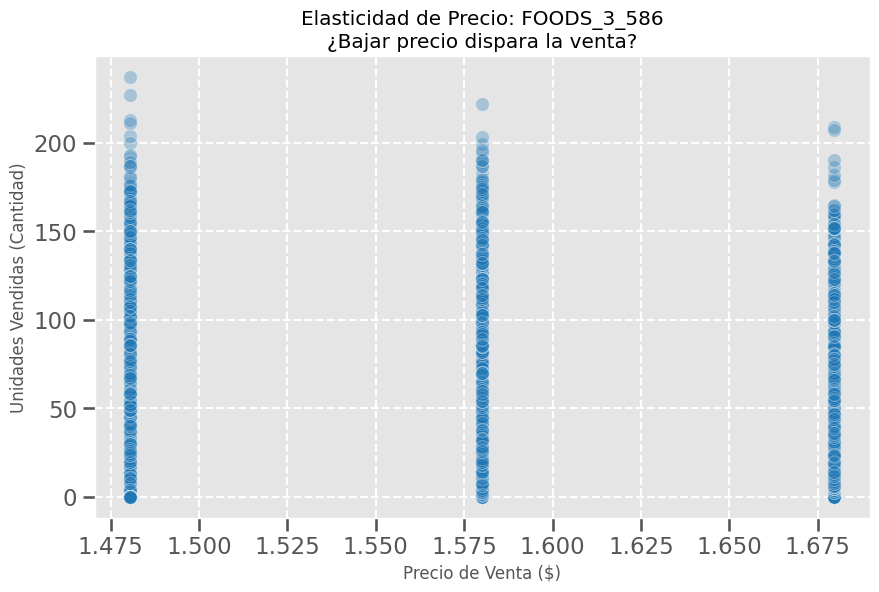

In [41]:
# 1. Filtramos un solo producto TOP para ver el efecto claro
# Buscamos el item que más dinero ha generado en la historia
top_item = df.groupby('item_id')['revenue'].sum().idxmax()
print(f"Analizando el producto estrella: {top_item}")

# 2. Extraemos sus datos
df_item = df[df['item_id'] == top_item].copy()

# 3. Scatter Plot: Precio vs Cantidad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_item, 
    x='sell_price', 
    y='sales', 
    alpha=0.3, # Transparencia para ver dónde se acumulan los puntos
    s=100      # Tamaño del punto
)

plt.title(f'Elasticidad de Precio: {top_item}\n¿Bajar precio dispara la venta?')
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Unidades Vendidas (Cantidad)')
plt.grid(True, linestyle='--')
plt.show()

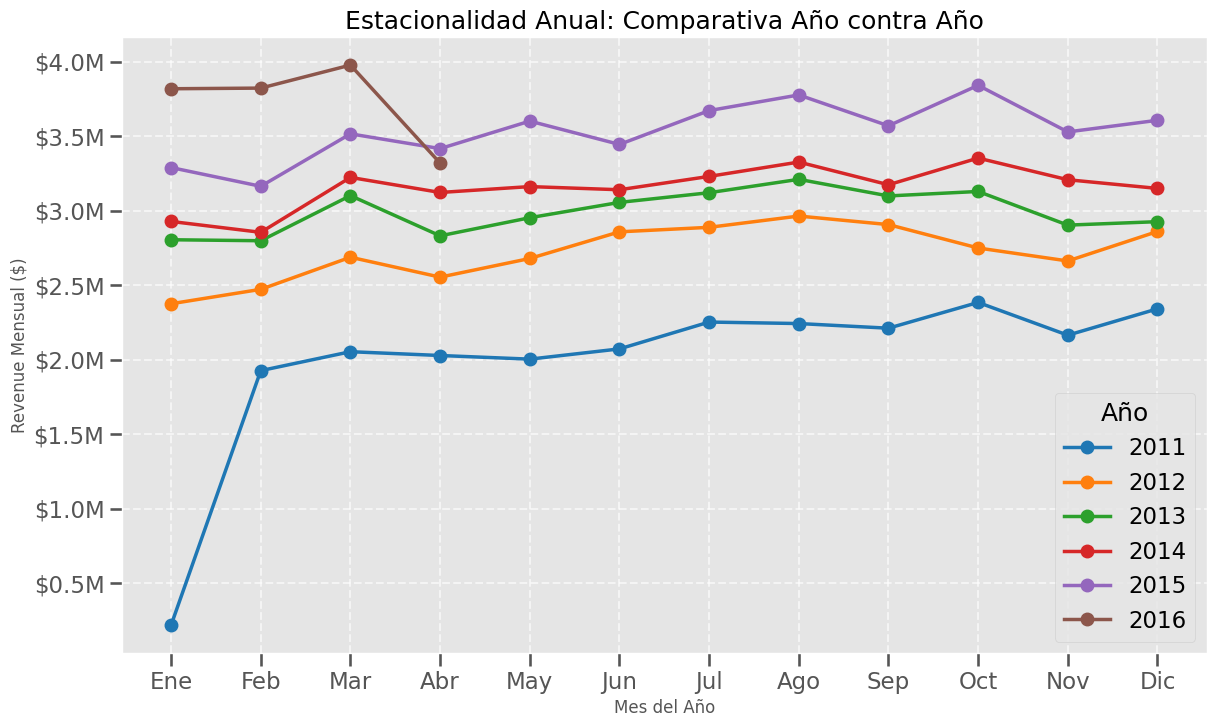

In [42]:


# 1. Preparación de Datos (Agregamos por Mes y Año)
# Aseguramos que tengamos las columnas de tiempo derivadas
# (Si ya las tienes, esto no daña nada)
if df['date'].dtype.name == 'category' or df['date'].dtype == 'object':
     df['date'] = pd.to_datetime(df['date'].astype(str))

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Agrupamos el ingreso total por Año y Mes
monthly_seasonality = df.groupby(['year', 'month'])['revenue'].sum().reset_index()

# 2. Pivot Table: Meses en filas (1-12), Años en columnas
# Esto es necesario para que matplotlib dibuje una línea por año
pivot_seasonality = monthly_seasonality.pivot(index='month', columns='year', values='revenue')

# 3. Graficar
plt.figure(figsize=(14, 8))
# Dibujamos todas las columnas (años)
plt.plot(pivot_seasonality, marker='o', linewidth=2.5)

plt.title('Estacionalidad Anual: Comparativa Año contra Año', fontsize=18)
plt.ylabel('Revenue Mensual ($)')
plt.xlabel('Mes del Año')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(pivot_seasonality.columns, title='Año')
plt.grid(True, linestyle='--', alpha=0.6)

# Formato de dinero en eje Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:,.1f}M'))

plt.show()

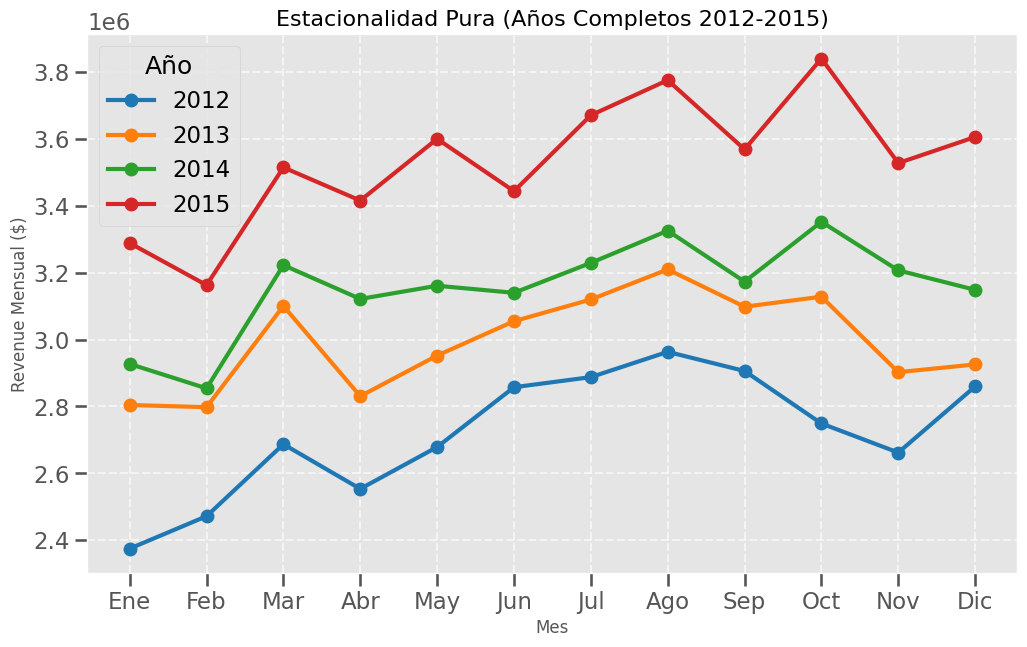

In [43]:
# Filtramos solo los años completos para ver el patrón real
df_clean_years = df[df['year'].isin([2012, 2013, 2014, 2015])]

# Agrupamos igual que antes
seasonality_clean = df_clean_years.groupby(['year', 'month'])['revenue'].sum().reset_index()
pivot_clean = seasonality_clean.pivot(index='month', columns='year', values='revenue')

# Graficamos limpio
plt.figure(figsize=(12, 7))
plt.plot(pivot_clean, marker='o', linewidth=3) # Líneas más gruesas

plt.title('Estacionalidad Pura (Años Completos 2012-2015)', fontsize=16)
plt.ylabel('Revenue Mensual ($)')
plt.xlabel('Mes')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(pivot_clean.columns, title='Año', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\3547049419.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_seasonality = df_clean_years.groupby(['year', 'month', 'cat_id'])['revenue'].sum().reset_index()


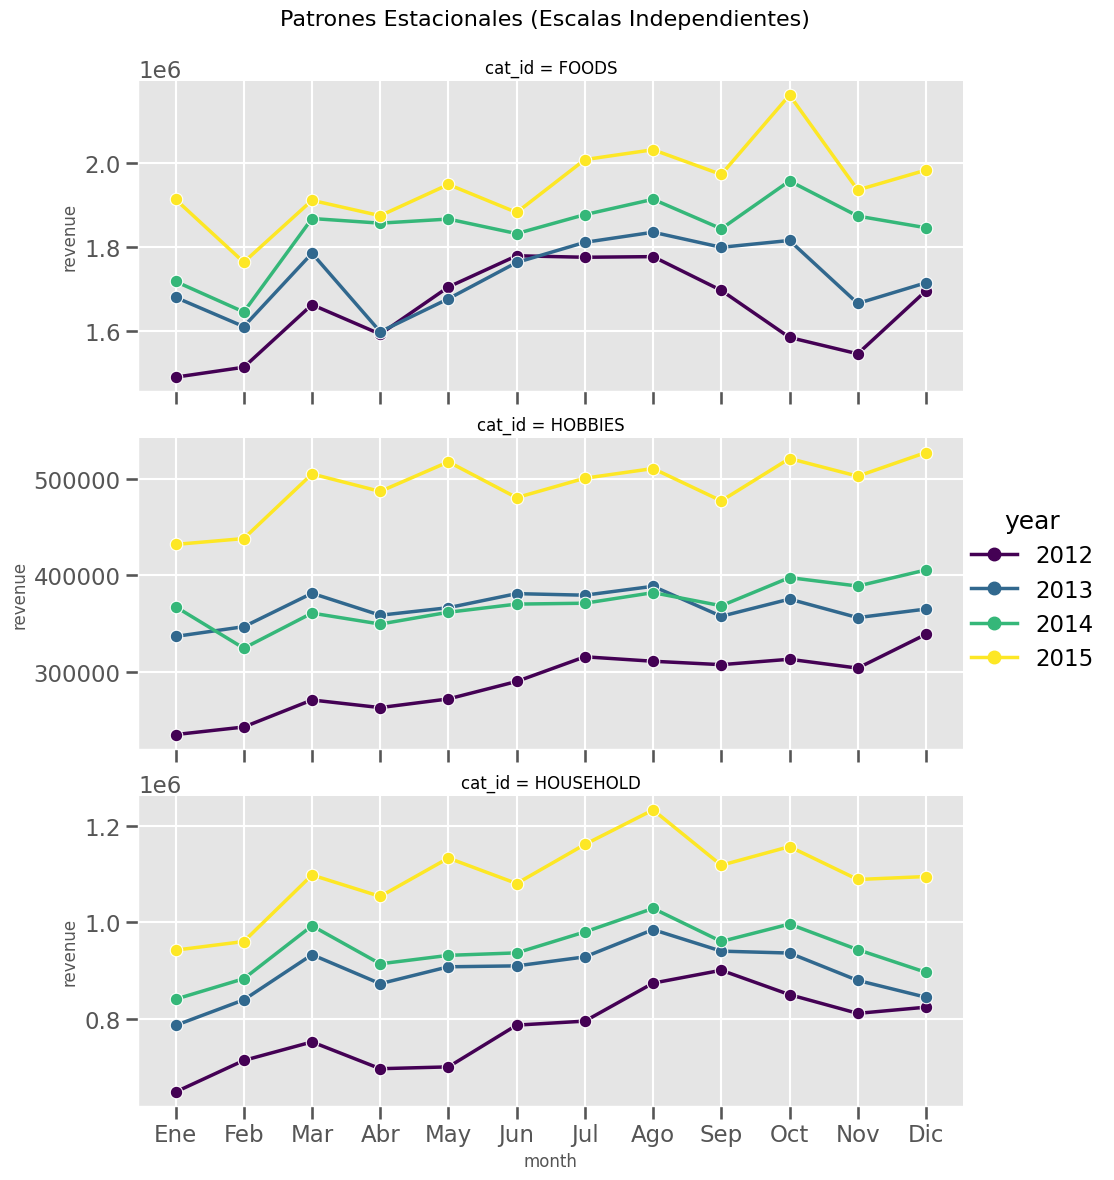

In [45]:
# 1. Filtramos años completos (2012-2015) para limpieza
# (Asumiendo que df_clean_years ya lo creaste en el paso anterior)
# Si no, ejecuta: df_clean_years = df[df['year'].isin([2012, 2013, 2014, 2015])]

# 2. Agrupamos por año, mes y categoría
cat_seasonality = df_clean_years.groupby(['year', 'month', 'cat_id'])['revenue'].sum().reset_index()

# 3. Graficamos con Escalas LIBRES (sharey=False)
g = sns.relplot(
    data=cat_seasonality,
    x='month', 
    y='revenue',
    hue='year',      
    col='cat_id',    # Columnas separadas
    col_wrap=1,      # Pone uno debajo del otro para que se vean grandes
    kind='line',
    height=4, 
    aspect=2.5,      # Más ancho para ver bien los meses
    linewidth=2.5,
    marker='o',
    palette='viridis',
    facet_kws={'sharey': False} # <--- LA MAGIA: Cada uno tiene su propia escala
)

# 4. Ajustes
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Patrones Estacionales (Escalas Independientes)', fontsize=16)
g.set(xticks=range(1, 13))
g.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.show()

In [ ]:
# 1. Creamos la columna unificada 'snap_active'
# Usamos np.select para hacerlo vectorizado y rapidísimo (Best Practice)
condiciones = [
    (df['state_id'] == 'CA') & (df['snap_CA'] == 1),
    (df['state_id'] == 'TX') & (df['snap_TX'] == 1),
    (df['state_id'] == 'WI') & (df['snap_WI'] == 1)
]

# Si cumple la condición es 1 (True), si no 0 (False)
# Nota: 'choices' debe ser [1, 1, 1] porque en los 3 casos es activo
df['snap_active'] = np.select(condiciones, [True, True, True], default=False)

Ingeniería de SNAP completada.


C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\3028299914.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snap_impact = df.groupby(['cat_id', 'snap_active'])['revenue'].mean().reset_index()
C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\3028299914.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


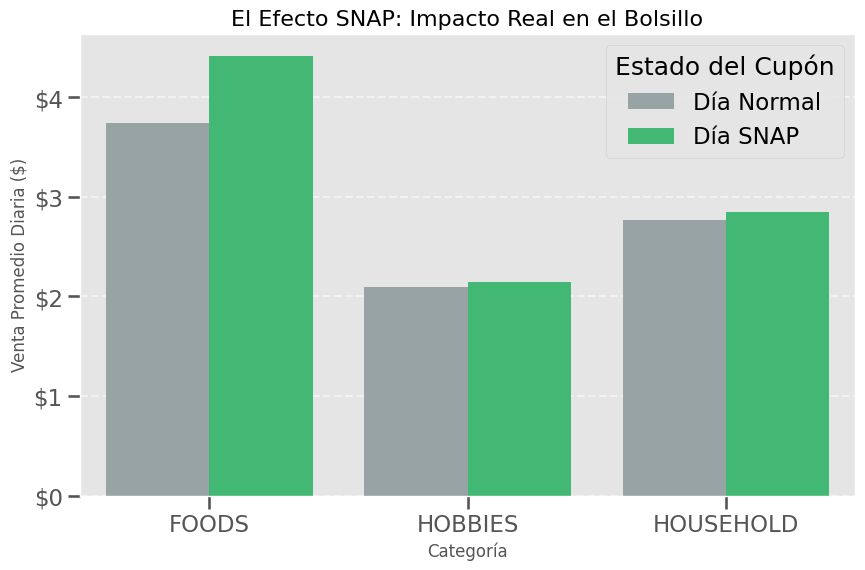

In [53]:
# 1. Aseguramos que la columna 'revenue' exista y no tenga nulos locos
# (Asumiendo que ya corriste la ingeniería de la variable 'snap_active' del paso anterior)

# 2. Agrupamos
snap_impact = df.groupby(['cat_id', 'snap_active'])['revenue'].mean().reset_index()

# 3. Graficamos
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=snap_impact, 
    x='cat_id', 
    y='revenue', 
    hue='snap_active', 
    palette={False: '#95a5a6', True: '#2ecc71'} # Gris vs Verde
)

plt.title('El Efecto SNAP: Impacto Real en el Bolsillo', fontsize=16)
plt.ylabel('Venta Promedio Diaria ($)')
plt.xlabel('Categoría')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Leyenda Limpia (Sin el error de labelcolor)
# Simplemente definimos las etiquetas manualmente
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ['Día Normal', 'Día SNAP'], title='Estado del Cupón')

# Formato de dinero en Eje Y
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

plt.show()

C:\Users\Santi\AppData\Local\Temp\ipykernel_7060\1943110288.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snap_cycle = df_foods.groupby(['state_id', 'day_of_month'])['revenue'].mean().reset_index()


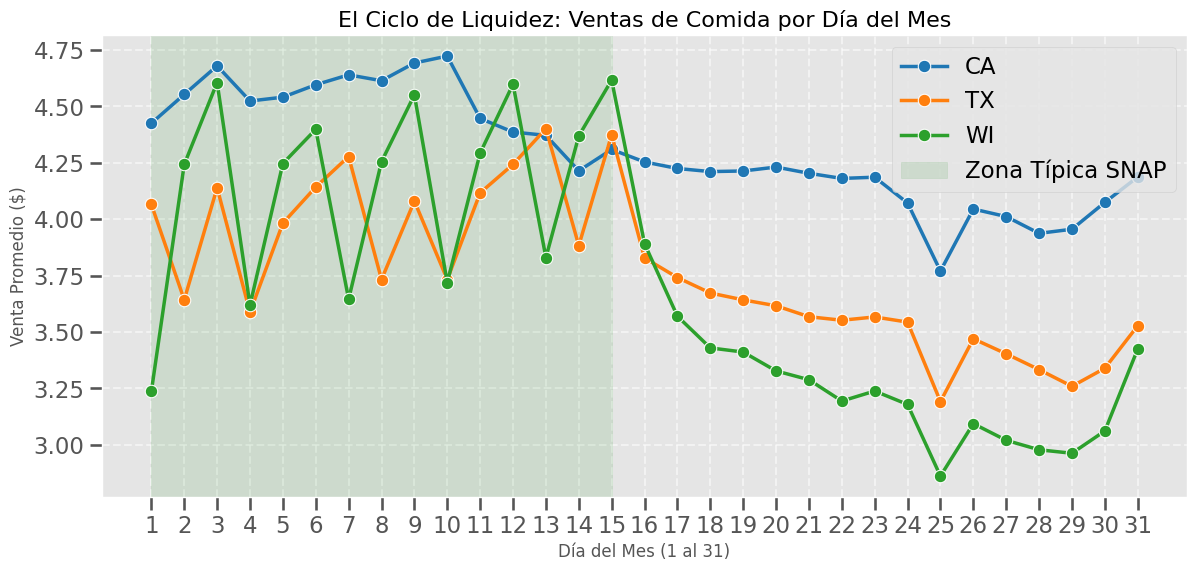

In [52]:
# 1. Extraemos el día del mes (si no lo tienes ya)
if df['date'].dtype.name == 'category' or df['date'].dtype == 'object':
     df['date'] = pd.to_datetime(df['date'].astype(str))
df['day_of_month'] = df['date'].dt.day

# 2. Filtramos SOLO COMIDA (que es lo que reacciona al SNAP)
df_foods = df[df['cat_id'] == 'FOODS']

# 3. Agrupamos por Estado y Día del Mes
snap_cycle = df_foods.groupby(['state_id', 'day_of_month'])['revenue'].mean().reset_index()

# 4. Graficamos
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=snap_cycle, 
    x='day_of_month', 
    y='revenue', 
    hue='state_id', 
    linewidth=2.5,
    marker='o'
)

plt.title('El Ciclo de Liquidez: Ventas de Comida por Día del Mes', fontsize=16)
plt.ylabel('Venta Promedio ($)')
plt.xlabel('Día del Mes (1 al 31)')
plt.xticks(range(1, 32)) # Mostrar todos los días
plt.grid(True, linestyle='--', alpha=0.5)

# Marcamos las zonas típicas de SNAP (del 1 al 15)
plt.axvspan(1, 15, color='green', alpha=0.1, label='Zona Típica SNAP')
plt.legend()

plt.show()